[Material used to generate Fig.8]

Time complexity of the different seepage expressions is computed in exp5.py
The exact solution refers to the numerical solution of the unsaturated Darcy equation at full disconnection. Transitional disconnection is not considered.
For the losed-form approximation, both transitional and full disconnection are computed. Also the static configuration means that the streambed properties are identical for all configurations, only stage and water table depth are allowed to change.

In [1]:
# Standard imports
import pathlib

# Third party imports
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# Internal imports

In [2]:
# set plot style
%matplotlib widget
plt.style.use('plot_style.txt')

# output path for figures 
output_path = pathlib.Path("/home/jonas/shared/Work/SSeep2026/Figures")

load data generated with exp5.py (m and s respectively indicate mean and standard deviations)

In [3]:
abs_m_vGM = pd.read_csv('../data/exp5_vGM_SAND/abs_m.csv', index_col=0)
abs_s_vGM = pd.read_csv('../data/exp5_vGM_SAND/abs_s.csv', index_col=0)
abs_m_BCB = pd.read_csv('../data/exp5_BCB_SAND/abs_m.csv', index_col=0)
abs_s_BCB = pd.read_csv('../data/exp5_BCB_SAND/abs_s.csv', index_col=0)

plot time complexity

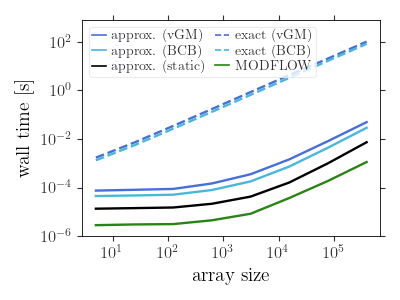

In [4]:
fig, ax = plt.subplots(figsize=(4, 3))
ax.spines["top"].set_visible(True)
ax.spines["right"].set_visible(True)
ax.tick_params(top=True, right=True)
ax.set(xscale='log', yscale='log')
ax.minorticks_off()


# set colors
c_mf = "#298513ff"
c_ex = "#000000ff"
c_vGM = "#476fdbff"
c_BCB = "#47b8dbff"



# set parametes use to generate the data
base = 5
n = 8
x = np.array([base**i for i in range(1, n + 1)])


# plot time complexity 

# MODFLOW
ax.plot(x, abs_m_vGM['mf'], ls='-', lw=1.7, c=c_mf, label='MODFLOW')

# closed-form vGM
ax.plot(x, abs_m_vGM['ap'], ls='-', lw=1.7, c=c_vGM, label='approx')

# closed-form BCB
ax.plot(x, abs_m_BCB['ap'], ls='-', lw=1.7, c=c_BCB, label='approx')

# closed-form vGM static
ax.plot(x, abs_m_vGM['ap st'], ls='-', lw=1.7, c='k', label='approx')

# closed-form BCB static
# ax.plot(x, abs_m_BCB['ap st'], ls=':',c=c_BCB, label='approx')

# exact vGM
ax.plot(x, abs_m_vGM['ex full'], ls='--', lw=1.7, c=c_vGM, label='exact full')

# exact BCB
ax.plot(x, abs_m_BCB['ex full'], ls='--', lw=1.7, c=c_BCB, label='exact full')



# layout
ax.set_ylim(ymax=8e2)
ax.set_xlabel('array size', labelpad=5)
ax.set_ylabel('wall time [s]', labelpad=5)
ax.set_xticks([1e1, 1e2, 1e3, 1e4, 1e5])
ax.set_yticks([1e-6, 1e-4, 1e-2, 1e0, 1e2])


legend = [Line2D([0], [0], ls='-', color=c_vGM, label='approx. (vGM)'),
          Line2D([0], [0], ls='-', color=c_BCB, label='approx. (BCB)'),
          Line2D([0], [0], ls='-', color='k', label='approx. (static)'),
          Line2D([0], [0], ls='--', color=c_vGM, label='exact (vGM)'),
          Line2D([0], [0], ls='--', color=c_BCB, label='exact (BCB)'),
          Line2D([0], [0], ls='-', color=c_mf, label='MODFLOW')]
          

plt.legend(handles=legend, fontsize=10, columnspacing=0.6, handlelength=1,
           labelspacing=0.1, handletextpad=0.4,         
           loc='upper left', bbox_to_anchor=(0.0, 1), ncols=2)


plt.tight_layout()
#plt.savefig(output_path / 'time_complexity.pdf')